# Phillips Curve in Brazil — Inflation & Unemployment Analysis

**Course:** Economic Data Lab — FGV EPGE  
**Author:** Tiago Ferreira Rodrigues  

---

Empirical analysis of the inflation–unemployment tradeoff in Brazil using official time-series data.

**Data sources:**
- IPCA (Consumer Price Index) — Banco Central do Brasil, SGS
- Unemployment rate — IBGE, PNADc (2012–2024)


Datasets: Retirei do Banco Central do Brasil, Sistema Gerenciador de Séries Temporais os seguintes datasets:
i) Índice de Preços ao Consumidor Amplo - IPCA
ii) Taxa de desocupação - PNADC

R: A observação de um dataset é precisamente a análise de seus elementos. Ou seja, como ele é composto, quais variáveis estão envolvidas, quantos dados estão presentes, se há erros identificáveis, se há inconsistências, etc. Nesse sentido, com relação aos datasets selecionados temos que: i) IPCA - apresenta duas colunas, uma sendo a Data e outra sendo o valor do IPCA. Os valores são str e float64, porém como era de interesse que as datas fossem lidas como tal, adaptei o código para transformá-las no formato datetime. ii) PNADC - segue um formato parecido com o dataset anterior, uma coluna contendo as datas e outra a taxa de desocupação(desemprego) correspondente, similarmente as datas foram transformadas em datetime e as taxas são float64. Os títulos das colunas de ambos os datasets seguem o valor de object.


P.S.: O dataset da PNADC possui dados apenas a partir de 2012, e também removi dos CSV's a última linha em que constava "Fonte: IBGE" para facilitar as análises posteriores.



In [2]:
import pandas as pd

ipca_data = pd.read_csv('IPCA.csv', encoding='latin1', sep=';', parse_dates=["Data"])
pnadc_data = pd.read_csv('PNADC.csv', encoding='latin1', sep=';', parse_dates=["Data"])


C:\Users\tiago\AppData\Local\Temp\ipykernel_23384\2970359962.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ipca_data = pd.read_csv('IPCA.csv', encoding='latin1', sep=';', parse_dates=["Data"])
C:\Users\tiago\AppData\Local\Temp\ipykernel_23384\2970359962.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pnadc_data = pd.read_csv('PNADC.csv', encoding='latin1', sep=';', parse_dates=["Data"])


In [ ]:
def convert_to_numeric(df, column_name):
    if df[column_name].dtype == object:
        df[column_name] = df[column_name].str.replace(',', '.').astype(float)
    return df

# Adjust numeric columns if stored as strings
ipca_data = convert_to_numeric(ipca_data, ipca_data.columns[1])
pnadc_data = convert_to_numeric(pnadc_data, pnadc_data.columns[1])

# Rename columns
ipca_data.columns = ['Data', 'IPCA']
pnadc_data.columns = ['Data', 'Taxa Desocupacao']

In [ ]:
ipca_data.head()

In [11]:
ipca_data.dtypes

Data    datetime64[ns]
IPCA           float64
dtype: object

In [12]:
pnadc_data.head()

,Data,Taxa Desocupacao
0,2012-01-03,8.0
1,2012-01-04,7.8
2,2012-01-05,7.7
3,2012-01-06,7.6
4,2012-01-07,7.5


In [13]:
pnadc_data.dtypes

Data                datetime64[ns]
Taxa Desocupacao           float64
dtype: object

### Condição 1

Verificando se há alguma taxa de desemprego fora do intervalo esperado (0 - 100%). 

Note que desemprego de -n% seria impossível, porém inflação de -n% seria possível (deflação).

In [14]:
desemprego_inconsistente = pnadc_data[(pnadc_data['Taxa Desocupacao'] < 0) | (pnadc_data['Taxa Desocupacao'] > 100)]
desemprego_inconsistente


,Data,Taxa Desocupacao


### Condição $2$

Verificando se há datas para as quais não há valores:

In [15]:

print(ipca_data.isnull().sum())
print(pnadc_data.isnull().sum())


Data    0
IPCA    0
dtype: int64
Data                0
Taxa Desocupacao    0
dtype: int64


In [16]:
ipca_stats = ipca_data['IPCA'].describe()
ipca_stats

count    538.000000
mean       5.710595
std       10.686507
min       -0.680000
25%        0.370000
50%        0.740000
75%        6.617500
max       82.390000
Name: IPCA, dtype: float64

In [17]:
pnadc_stats = pnadc_data['Taxa Desocupacao'].describe()
pnadc_stats

count    152.000000
mean      10.096711
std        2.644109
min        6.200000
25%        7.600000
50%        9.700000
75%       12.325000
max       14.900000
Name: Taxa Desocupacao, dtype: float64

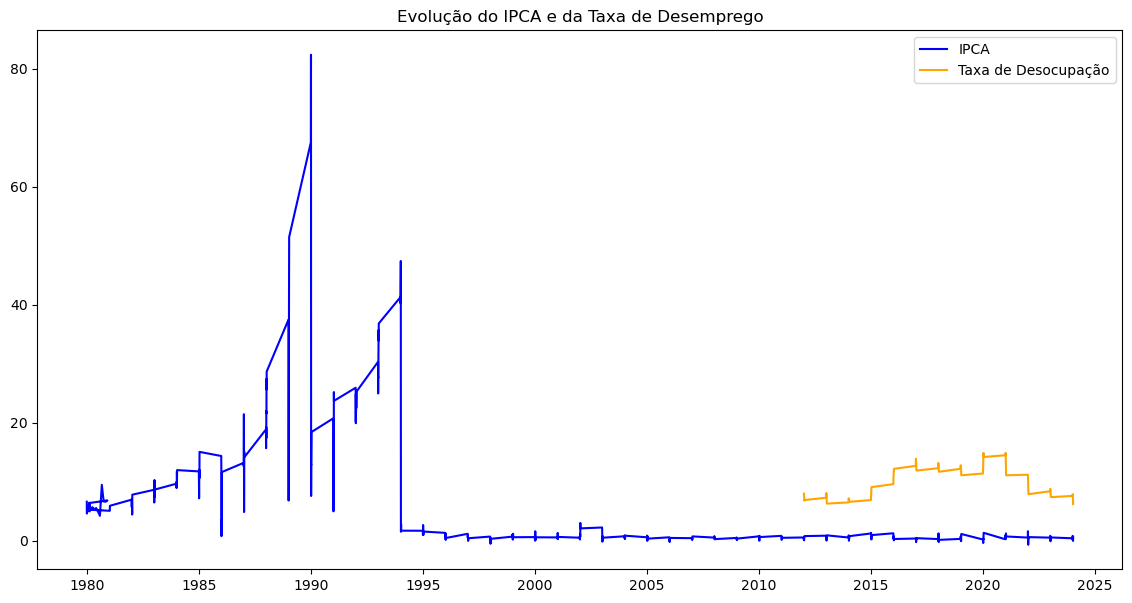

In [19]:
import matplotlib.pyplot as plt

#Gráfico da inflação e do desemprego ao longo do tempo
plt.figure(figsize=(14, 7))
plt.plot(ipca_data['Data'], ipca_data['IPCA'], label='IPCA', color='blue')
plt.plot(pnadc_data['Data'], pnadc_data['Taxa Desocupacao'], label='Taxa de Desocupação', color='orange')
plt.title('Evolução do IPCA e da Taxa de Desemprego')
plt.legend()
plt.show()

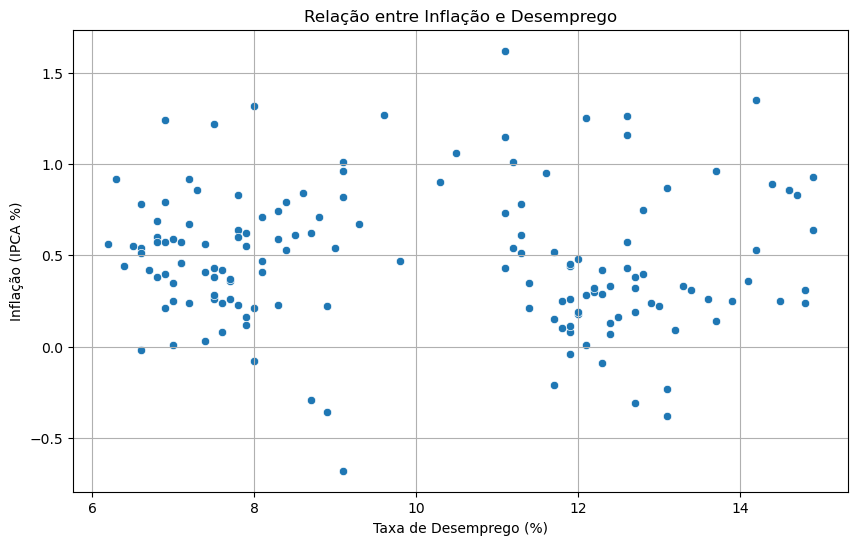

In [20]:
import seaborn as sns
#Gráfico scatterplot inflação x desemprego

dados_merged = pd.merge(ipca_data, pnadc_data, on='Data', how='inner')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=dados_merged, x='Taxa Desocupacao', y='IPCA')

plt.title('Relação entre Inflação e Desemprego')
plt.xlabel('Taxa de Desemprego (%)')
plt.ylabel('Inflação (IPCA %)')
plt.grid(True)
plt.show()


### Curva de Phillips

Qual a relação entre a taxa de desemprego e a inflação? Ela segue a relação esperada pela curva de phillips?

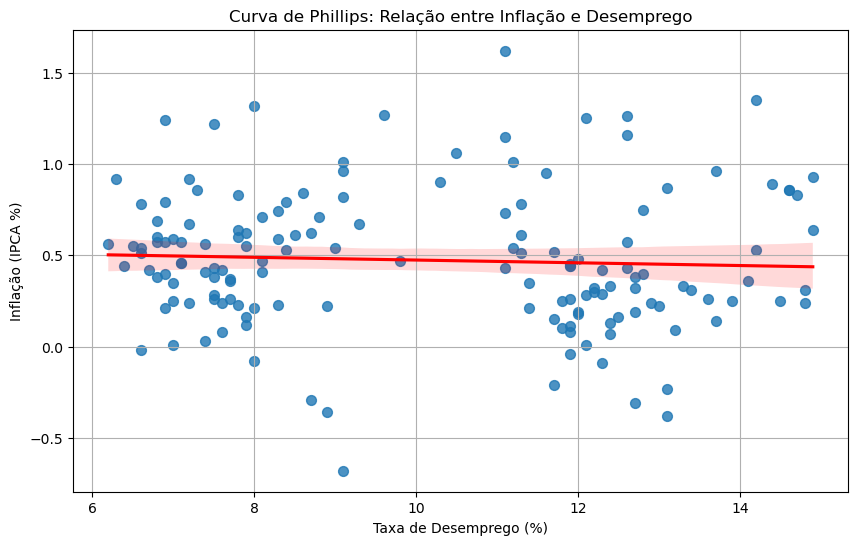

In [21]:
# Scatterplot com regressão
plt.figure(figsize=(10, 6))
sns.regplot(data=dados_merged, x='Taxa Desocupacao', y='IPCA', scatter_kws={'s': 50}, line_kws={"color": "red"})

plt.title('Curva de Phillips: Relação entre Inflação e Desemprego')
plt.xlabel('Taxa de Desemprego (%)')
plt.ylabel('Inflação (IPCA %)')
plt.grid(True)
plt.show()

### Evolução da inflação e do desemprego
O que explica as variações observadas da inflação e do desemprego? 

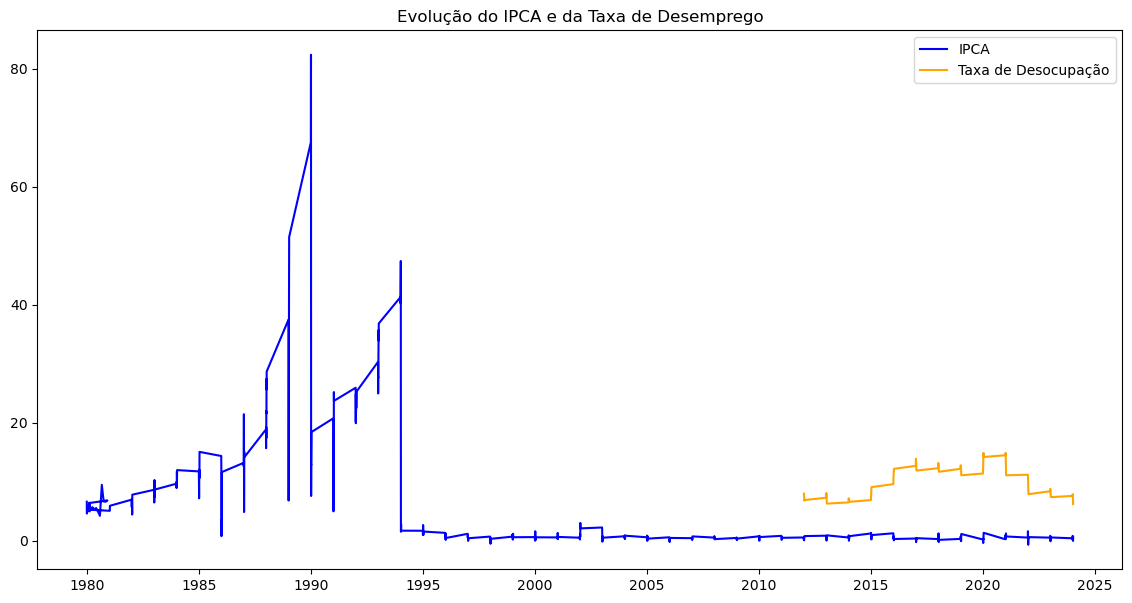

In [22]:
plt.figure(figsize=(14, 7))
plt.plot(ipca_data['Data'], ipca_data['IPCA'], label='IPCA', color='blue')
plt.plot(pnadc_data['Data'], pnadc_data['Taxa Desocupacao'], label='Taxa de Desocupação', color='orange')
plt.title('Evolução do IPCA e da Taxa de Desemprego')
plt.legend()
plt.show()